# ch06/optimizer_compare_naive.py

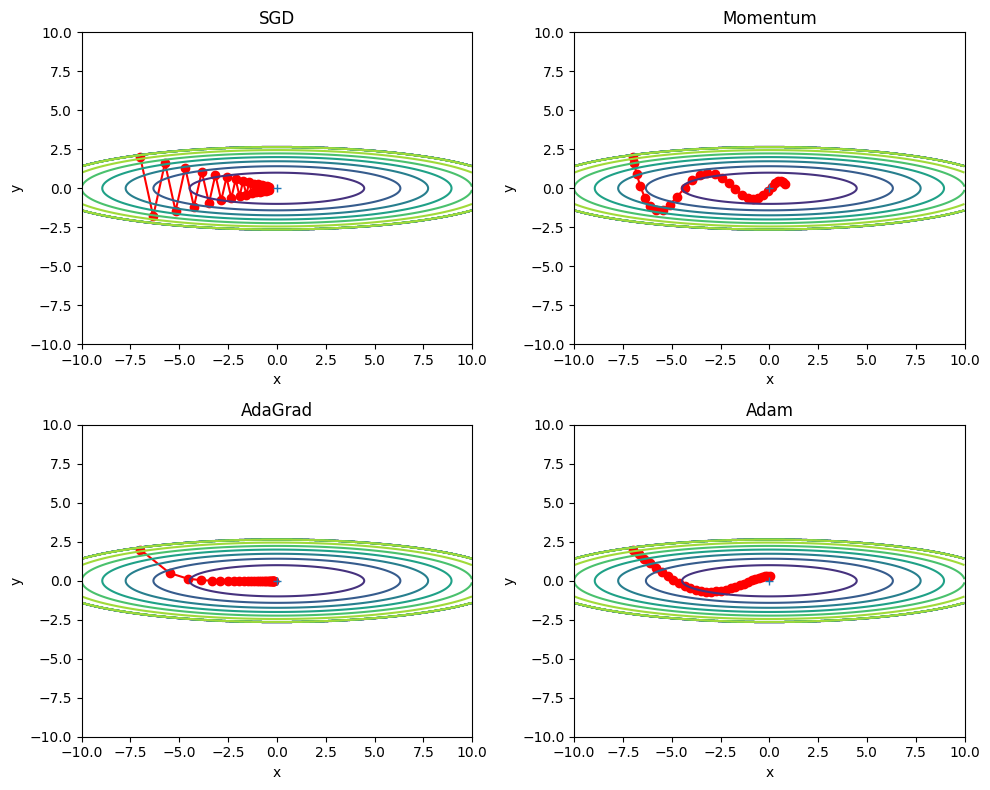

In [26]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1
plt.figure(figsize=(10, 8))

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # for simple contour line  
    mask = Z > 7
    Z[mask] = 0
    
    # plot 
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.tight_layout()
plt.show()

In [27]:
# Cell 1 の関数 f / df、init_pos、optimizers をそのまま利用して
# 3D で最適化経路をインタラクティブ可視化（上側をトリミング + アニメーション）
import numpy as np

try:
    import plotly.graph_objects as go
except ImportError:
    raise ImportError("plotly が必要です。`pip install plotly` を実行してください。")

params_3d = {'x': init_pos[0], 'y': init_pos[1]}
grads_3d = {'x': 0.0, 'y': 0.0}

trajectory = {}
for key in optimizers:
    optimizer = optimizers[key]
    params_3d['x'], params_3d['y'] = init_pos

    xs, ys, zs = [], [], []
    for _ in range(30):
        x, y = params_3d['x'], params_3d['y']
        xs.append(x)
        ys.append(y)
        zs.append(f(x, y))

        grads_3d['x'], grads_3d['y'] = df(x, y)
        optimizer.update(params_3d, grads_3d)

    trajectory[key] = (np.array(xs), np.array(ys), np.array(zs))

x = np.linspace(-10, 10, 120)
y = np.linspace(-5, 5, 120)
X, Y = np.meshgrid(x, y)
Z_raw = f(X, Y)

# 関数上部をトリミングして見やすくする
z_cap = 12.0
Z = np.clip(Z_raw, 0, z_cap)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale='Viridis',
    opacity=0.72,
    showscale=False,
    name='f(x, y)'
))

colors = {
    'SGD': '#EF553B',
    'Momentum': '#00CC96',
    'AdaGrad': '#636EFA',
    'Adam': '#FFA15A'
}

keys = list(trajectory.keys())
for key in keys:
    xs, ys, zs = trajectory[key]
    fig.add_trace(go.Scatter3d(
        x=xs[:1], y=ys[:1], z=np.clip(zs[:1], 0, z_cap),
        mode='lines+markers',
        name=key,
        line=dict(width=6, color=colors.get(key, '#FFFFFF')),
        marker=dict(size=3, color=colors.get(key, '#FFFFFF'))
    ))

n_steps = max(len(v[0]) for v in trajectory.values())
frames = []
for t in range(n_steps):
    frame_data = []
    for key in keys:
        xs, ys, zs = trajectory[key]
        frame_data.append(go.Scatter3d(
            x=xs[:t+1],
            y=ys[:t+1],
            z=np.clip(zs[:t+1], 0, z_cap),
            mode='lines+markers',
            line=dict(width=6, color=colors.get(key, '#FFFFFF')),
            marker=dict(size=3, color=colors.get(key, '#FFFFFF'))
        ))
    frames.append(go.Frame(data=frame_data, traces=list(range(1, 1 + len(keys))), name=str(t)))

fig.frames = frames

fig.update_layout(
    title='Optimizer Trajectories on f(x, y) = x^2/20 + y^2',
    width=1000,
    height=700,
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)',
        zaxis=dict(range=[0, z_cap]),
        camera=dict(eye=dict(x=1.5, y=1.25, z=0.8))
    ),
    legend=dict(x=0.02, y=0.98),
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'x': 0.02,
        'y': 1.08,
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 140, 'redraw': True}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]}
        ]
    }],
    sliders=[{
        'active': 0,
        'x': 0.18,
        'y': 1.06,
        'len': 0.75,
        'steps': [
            {'label': str(t), 'method': 'animate', 'args': [[str(t)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}}]}
            for t in range(n_steps)
        ]
    }]
)

fig.show()


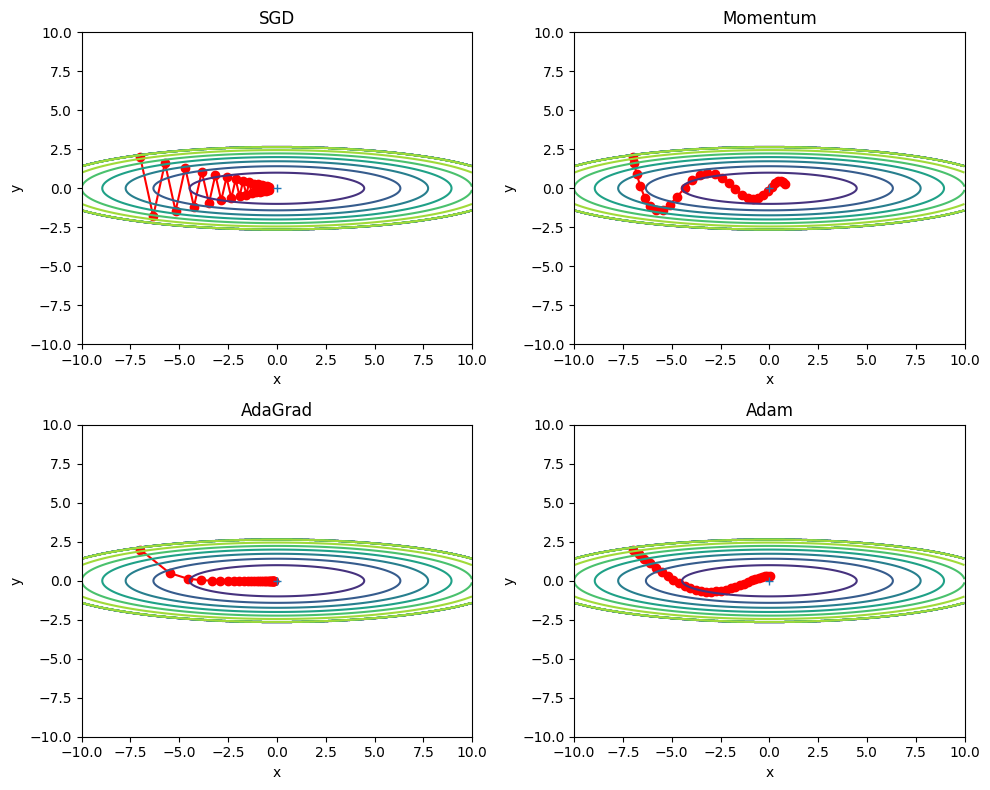

In [15]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1
plt.figure(figsize=(10, 8))

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # for simple contour line  
    mask = Z > 7
    Z[mask] = 0
    
    # plot 
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.tight_layout()
plt.show()

# ch06/optimizer_compare_mnist.py

===========iteration:0===========
SGD:2.3552897324047866
Momentum:2.361099438306561
AdaGrad:2.404846932983569
Adam:2.2828951272429863
===========iteration:100===========
SGD:1.5708821931232821
Momentum:0.3046052565263182
AdaGrad:0.1127252288187777
Adam:0.23820927332577974
===========iteration:200===========
SGD:0.752170369787196
Momentum:0.2538277144973096
AdaGrad:0.09713951798898124
Adam:0.16718268982363826
===========iteration:300===========
SGD:0.4367250809477158
Momentum:0.1918328198257877
AdaGrad:0.08696837097912721
Adam:0.0843038621209662
===========iteration:400===========
SGD:0.537314468307891
Momentum:0.21419958640227185
AdaGrad:0.12247505142912372
Adam:0.24918190356536407
===========iteration:500===========
SGD:0.3496018034924627
Momentum:0.20029327833975427
AdaGrad:0.06498092508229888
Adam:0.1575114589536478
===========iteration:600===========
SGD:0.38783528986861626
Momentum:0.1260498668609716
AdaGrad:0.04816691486380169
Adam:0.05235616629985174
===========iteration:700====

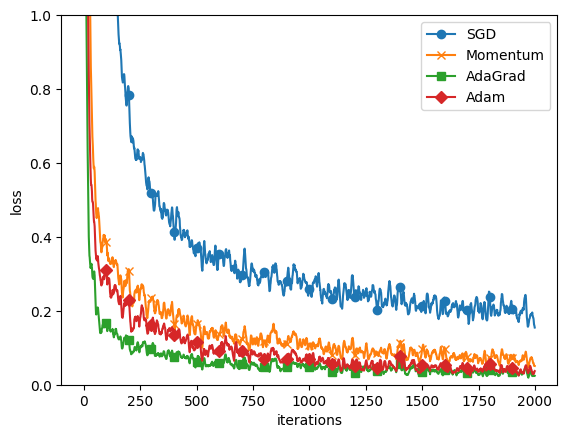

In [16]:
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0:MNISTデータの読み込み==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:実験の設定==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    


# 2:訓練の開始==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.グラフの描画==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()


# ch06/weight_init_activation_histogram.py

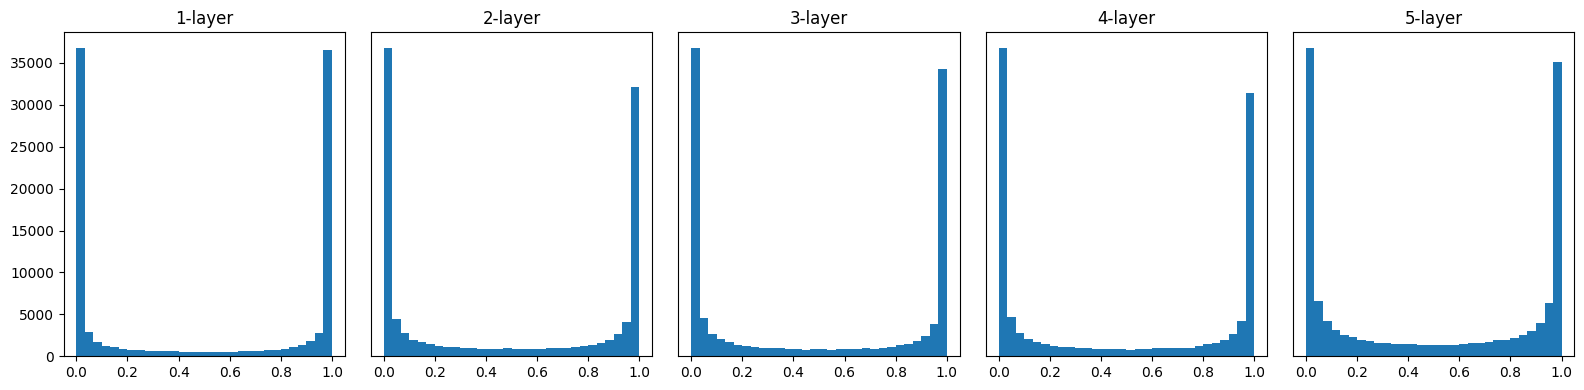

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)
    
input_data = np.random.randn(1000, 100)  # 1000個のデータ
node_num = 100  # 各隠れ層のノード（ニューロン）の数
hidden_layer_size = 5  # 隠れ層が5層
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 初期値の値をいろいろ変えて実験しよう！
    w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)


    # 活性化関数の種類も変えて実験しよう！
    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# ヒストグラムを描画
plt.figure(figsize=(16, 4))
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.tight_layout()
plt.show()


# ch06/weight_init_compare.py

In [ ]:
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0:MNISTデータの読み込み==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:実験の設定==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2:訓練の開始==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.グラフの描画==========
plt.figure(figsize=(14, 10))
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

===========iteration:0===========
std=0.01:2.302493187727284
Xavier:2.2981594049777208
He:2.3759492352742875


# ch06/batch_norm_gradient_check.py

In [ ]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100], output_size=10,
                              use_batchnorm=True)

x_batch = x_train[:1]
t_batch = t_train[:1]

grad_backprop = network.gradient(x_batch, t_batch)
grad_numerical = network.numerical_gradient(x_batch, t_batch)


for key in grad_numerical.keys():
    diff = np.average( np.abs(grad_backprop[key] - grad_numerical[key]) )
    print(key + ":" + str(diff))

W1:0.0
b1:0.0
gamma1:0.0
beta1:0.0
W2:0.0
b2:0.0
gamma2:0.0
beta2:0.049839929248629566
W3:0.0
b3:1.7990402263745597e-07


# ch06/batch_norm_test.py

============== 1/16 ==============
epoch:0 | 0.099 - 0.117
epoch:1 | 0.097 - 0.122


/home/user/deep-learning-from-scratch/my_notebooks/../common/multi_layer_net_extend.py:101: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
/home/user/deep-learning-from-scratch/my_notebooks/../common/multi_layer_net_extend.py:101: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
/home/user/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/user/deep-learning-from-scratch/my_notebooks/../common/functions.py:32: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=-1, keepdims=True)   # オーバーフロー対策


epoch:2 | 0.097 - 0.111
epoch:3 | 0.097 - 0.124
epoch:4 | 0.097 - 0.144
epoch:5 | 0.097 - 0.163
epoch:6 | 0.097 - 0.185
epoch:7 | 0.097 - 0.201
epoch:8 | 0.097 - 0.226
epoch:9 | 0.097 - 0.242
epoch:10 | 0.097 - 0.256
epoch:11 | 0.097 - 0.273
epoch:12 | 0.097 - 0.291
epoch:13 | 0.097 - 0.308
epoch:14 | 0.097 - 0.333
epoch:15 | 0.097 - 0.354
epoch:16 | 0.097 - 0.357
epoch:17 | 0.097 - 0.369
epoch:18 | 0.097 - 0.382
epoch:19 | 0.097 - 0.398
============== 2/16 ==============
epoch:0 | 0.097 - 0.094
epoch:1 | 0.097 - 0.072


/tmp/ipykernel_2710/3981854078.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


epoch:2 | 0.097 - 0.096
epoch:3 | 0.097 - 0.139
epoch:4 | 0.097 - 0.166
epoch:5 | 0.097 - 0.202
epoch:6 | 0.097 - 0.233
epoch:7 | 0.097 - 0.257
epoch:8 | 0.097 - 0.282
epoch:9 | 0.097 - 0.296
epoch:10 | 0.097 - 0.318
epoch:11 | 0.097 - 0.342
epoch:12 | 0.097 - 0.368
epoch:13 | 0.097 - 0.371
epoch:14 | 0.097 - 0.391
epoch:15 | 0.097 - 0.406
epoch:16 | 0.097 - 0.427
epoch:17 | 0.097 - 0.442
epoch:18 | 0.097 - 0.46
epoch:19 | 0.097 - 0.469
============== 3/16 ==============
epoch:0 | 0.119 - 0.086
epoch:1 | 0.285 - 0.068
epoch:2 | 0.446 - 0.097
epoch:3 | 0.503 - 0.151
epoch:4 | 0.555 - 0.207
epoch:5 | 0.628 - 0.249
epoch:6 | 0.666 - 0.277
epoch:7 | 0.693 - 0.313
epoch:8 | 0.736 - 0.347
epoch:9 | 0.767 - 0.382
epoch:10 | 0.802 - 0.416
epoch:11 | 0.829 - 0.449
epoch:12 | 0.837 - 0.471
epoch:13 | 0.864 - 0.492
epoch:14 | 0.893 - 0.507
epoch:15 | 0.889 - 0.543
epoch:16 | 0.913 - 0.565
epoch:17 | 0.913 - 0.578
epoch:18 | 0.925 - 0.598
epoch:19 | 0.924 - 0.606
============== 4/16 ==============

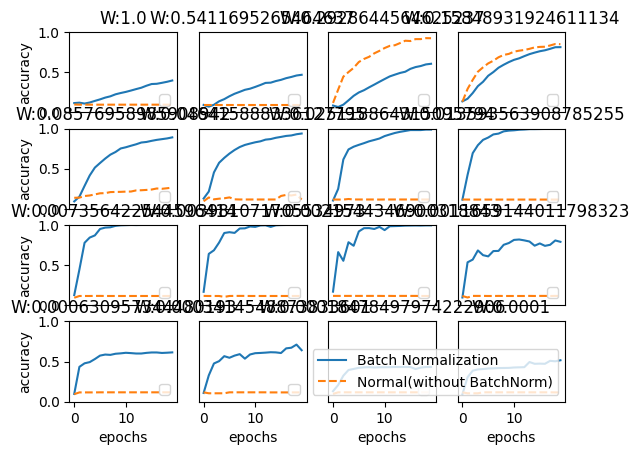

In [ ]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 3.グラフの描画==========
plt.figure(figsize=(14, 10))
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    if i == 15:
        plt.legend(loc='lower right')
    
plt.tight_layout()
plt.show()

# ch06/overfit_weight_decay.py

epoch:0, train acc:0.1, test acc:0.1119
epoch:1, train acc:0.11, test acc:0.1215
epoch:2, train acc:0.12666666666666668, test acc:0.1287
epoch:3, train acc:0.15333333333333332, test acc:0.147
epoch:4, train acc:0.16333333333333333, test acc:0.1629
epoch:5, train acc:0.18666666666666668, test acc:0.1758
epoch:6, train acc:0.21666666666666667, test acc:0.1912
epoch:7, train acc:0.23666666666666666, test acc:0.2047
epoch:8, train acc:0.2733333333333333, test acc:0.2195
epoch:9, train acc:0.3233333333333333, test acc:0.2347
epoch:10, train acc:0.35333333333333333, test acc:0.2433
epoch:11, train acc:0.37, test acc:0.258
epoch:12, train acc:0.4, test acc:0.2791
epoch:13, train acc:0.4, test acc:0.2896
epoch:14, train acc:0.41333333333333333, test acc:0.303
epoch:15, train acc:0.44333333333333336, test acc:0.3277
epoch:16, train acc:0.45666666666666667, test acc:0.3398
epoch:17, train acc:0.46, test acc:0.3477
epoch:18, train acc:0.49333333333333335, test acc:0.3627
epoch:19, train acc:0.503

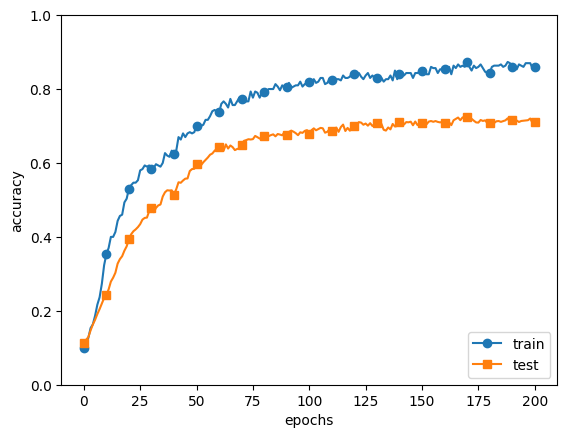

In [ ]:
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
#weight_decay_lambda = 0 # weight decayを使用しない場合
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# ch06/overfit_dropout.py

train loss:2.318257622773167
=== epoch:1, train acc:0.09666666666666666, test acc:0.1068 ===
train loss:2.304160972839927
train loss:2.304238285036127
train loss:2.319282104046709
=== epoch:2, train acc:0.10666666666666667, test acc:0.1098 ===
train loss:2.3040465702088833
train loss:2.2915756322771483
train loss:2.3008662742099575
=== epoch:3, train acc:0.11666666666666667, test acc:0.1155 ===
train loss:2.2944573019416747
train loss:2.3117702374814035
train loss:2.306005593310487
=== epoch:4, train acc:0.12, test acc:0.1202 ===
train loss:2.3077651192937734
train loss:2.3046222345880403
train loss:2.332488356182796
=== epoch:5, train acc:0.12666666666666668, test acc:0.1233 ===
train loss:2.298987996724874
train loss:2.2910832116117525
train loss:2.288158086873575
=== epoch:6, train acc:0.13, test acc:0.1284 ===
train loss:2.28625668504479
train loss:2.3092680285943525
train loss:2.306896912690104
=== epoch:7, train acc:0.13, test acc:0.1299 ===
train loss:2.294059781757892
train los

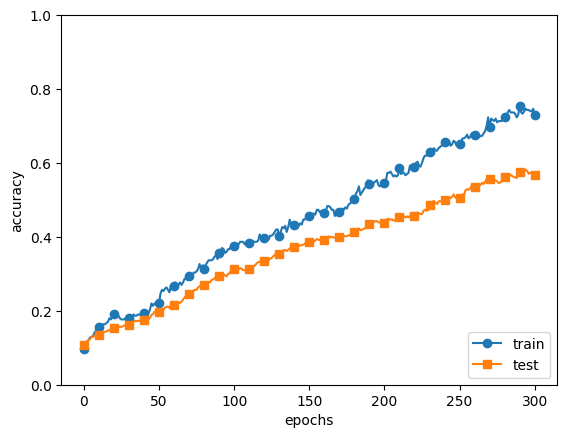

In [ ]:
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# Dropuoutの有無、割り合いの設定 ========================
use_dropout = True  # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# ch06/hyperparameter_optimization.py

In [ ]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 高速化のため訓練データの削減
x_train = x_train[:500]
t_train = t_train[:500]

# 検証データの分離
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# ハイパーパラメータのランダム探索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 探索したハイパーパラメータの範囲を指定===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# グラフの描画========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0
plt.figure(figsize=(15, 10))

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.tight_layout()
plt.show()

val acc:0.09 | lr:2.867488615434035e-06, weight decay:2.016473583253835e-08
val acc:0.13 | lr:7.851391221347583e-06, weight decay:1.4581757587126898e-07
val acc:0.15 | lr:0.0005835236857614753, weight decay:7.654719735470597e-06
val acc:0.09 | lr:6.4340550032043334e-06, weight decay:1.8790966704108312e-06
val acc:0.32 | lr:0.0017726259066605712, weight decay:1.3896300757656847e-06
val acc:0.14 | lr:0.00029645336626331516, weight decay:3.7005365352501165e-08
val acc:0.15 | lr:0.00016453060211709625, weight decay:2.3334689762322694e-06
val acc:0.12 | lr:1.5342138586708545e-06, weight decay:2.2704699046298246e-08
val acc:0.11 | lr:7.198809817904433e-06, weight decay:7.424369532518489e-08
val acc:0.46 | lr:0.00182630756942452, weight decay:3.897081385446632e-05
val acc:0.13 | lr:7.99543532640809e-05, weight decay:4.87645635982515e-06
val acc:0.77 | lr:0.00791728144066649, weight decay:7.287475223746355e-07
val acc:0.06 | lr:5.429240013049346e-05, weight decay:8.498975550734368e-08
val acc: